In [1]:
!pip install xgboost==1.7.6 pandas pyarrow joblib


In [2]:
import pandas as pd
import numpy as np

dtypes = {
    "purpose_bucket": "category",
    "zip3": "category",
    "state_cat": "category",
    "emp_length_clean": "float32",
    "amount_requested": "float32",
    "dti_clean": "float32",
    "months_since_start": "int32",
    "approval_status": "int8"
}
DATA_PATH = "approval_full_preprocessed2.0.csv"

df = pd.read_csv(DATA_PATH, dtype=dtypes)
print(df.shape, df.memory_usage(deep=True).sum() / 1024**3, "GB")


(29907404, 10) 1.0306704873219132 GB


In [3]:
cutoff = df["months_since_start"].quantile(0.80)
print("Time cutoff:", cutoff)
train_df = df[df["months_since_start"] <= cutoff]
test_df  = df[df["months_since_start"] > cutoff]

print("Train:", train_df.shape)
print("Test:", test_df.shape)


Time cutoff: 138.0
Train: (24471675, 10)
Test: (5435729, 10)


In [4]:
import joblib

cat_maps = joblib.load("cat_maps_full.joblib")
cat_cols = ["purpose_bucket", "zip3", "state_cat"]

def apply_maps(df, cat_maps):
    for c, mapping in cat_maps.items():
        df[c + "_code"] = (
            df[c].astype(str)
                  .map(lambda x: mapping.get(x, -1))
                  .astype("int32")
        )
    return df

train_df = apply_maps(train_df, cat_maps)
test_df  = apply_maps(test_df, cat_maps)
train_df = train_df.drop(columns=cat_cols)
test_df  = test_df.drop(columns=cat_cols)


/tmp/ipykernel_3307/2763576686.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[c + "_code"] = (
/tmp/ipykernel_3307/2763576686.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[c + "_code"] = (
/tmp/ipykernel_3307/2763576686.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-

In [9]:
!pip install xgboost --quiet
import xgboost as xgb

feature_cols = [
    "emp_length_clean",
    "amount_requested",
    "dti_clean",
    "months_since_start",
    "purpose_bucket_code",
    "zip3_code",
    "state_cat_code"
]

dtrain = xgb.DMatrix(train_df[feature_cols], label=train_df["approval_status"])
dtest  = xgb.DMatrix(test_df[feature_cols],  label=test_df["approval_status"])


In [10]:
pos = train_df["approval_status"].sum()
neg = (train_df["approval_status"] == 0).sum()
scale_pos_weight = neg / pos

print("scale_pos_weight =", scale_pos_weight)


scale_pos_weight = 11.218157825626319


In [11]:
tree_method = "hist"
params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "min_child_weight": 5,
    "tree_method": tree_method,
    "scale_pos_weight": scale_pos_weight
}

bst = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dtest, "validation")],
    early_stopping_rounds=50,
    verbose_eval=50
)
bst.save_model("xgb_model_full.json")
print("Saved model.")

from sklearn.isotonic import IsotonicRegression

raw_pred = bst.predict(dtest)
y_test = test_df["approval_status"].values

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(raw_pred, y_test)

joblib.dump(iso, "isotonic_full.joblib")
print("Saved isotonic calibrator.")


[0]	validation-auc:0.74605
[50]	validation-auc:0.96048
[100]	validation-auc:0.96211
[150]	validation-auc:0.96302
[200]	validation-auc:0.96345
[250]	validation-auc:0.96375
[300]	validation-auc:0.96394
[350]	validation-auc:0.96408
[400]	validation-auc:0.96420
[450]	validation-auc:0.96427
[500]	validation-auc:0.96434
[550]	validation-auc:0.96439
[600]	validation-auc:0.96445
[650]	validation-auc:0.96448
[700]	validation-auc:0.96450
[750]	validation-auc:0.96452
[800]	validation-auc:0.96453
[850]	validation-auc:0.96455
[900]	validation-auc:0.96457
[950]	validation-auc:0.96459
[1000]	validation-auc:0.96460
[1050]	validation-auc:0.96461
[1083]	validation-auc:0.96460
Saved model.
Saved isotonic calibrator.



========== BASIC METRICS ==========
AUC:                  0.964603
Log Loss:             0.152016
Average Precision:    0.692795
Accuracy:             0.950455
Precision:            0.485552
Recall:               0.869688
F1 Score:             0.623179
Brier Score:          0.040601
Best Iteration:       1034

========== CONFUSION MATRIX ==========


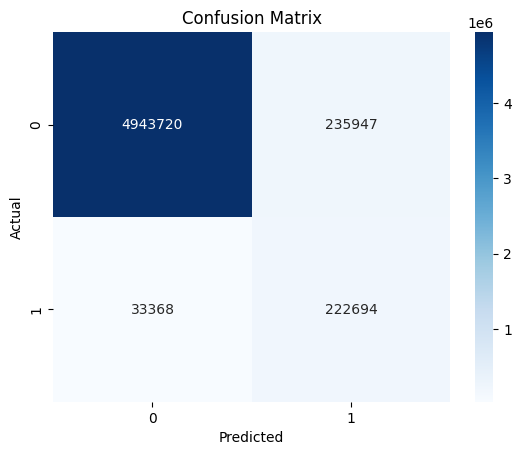

========== ROC CURVE ==========


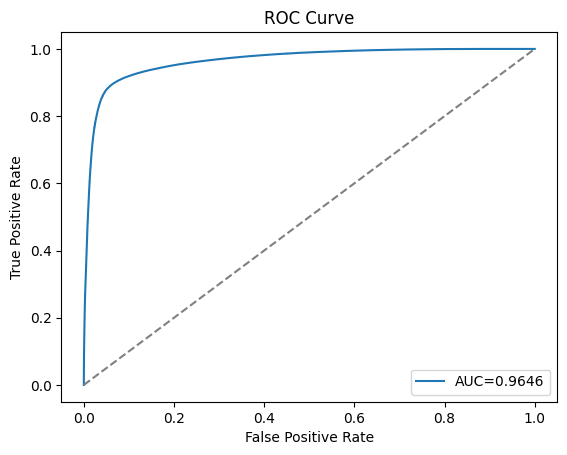

========== PRECISION-RECALL CURVE ==========


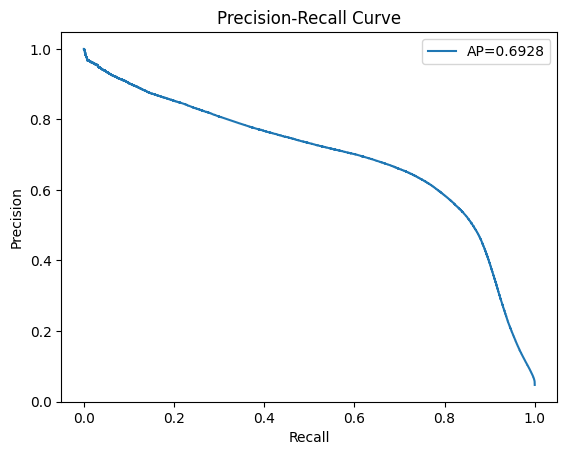

========== FEATURE IMPORTANCE ==========


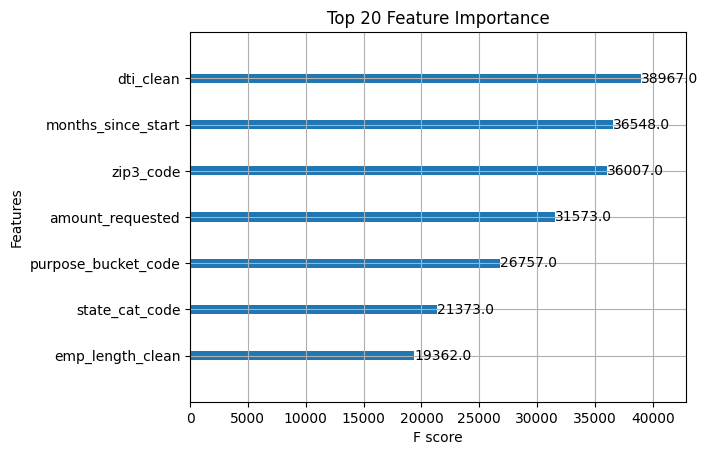


All metrics plotted.



In [16]:
import numpy as np
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, average_precision_score,
    log_loss, precision_recall_curve, brier_score_loss
)
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Raw model predictions
# ===============================
raw_pred = bst.predict(dtest)
y_test = test_df["approval_status"].values

# ===============================
# 2. Basic metrics
# ===============================
print("\n========== BASIC METRICS ==========")
auc = roc_auc_score(y_test, raw_pred)
logloss = log_loss(y_test, raw_pred)
ap = average_precision_score(y_test, raw_pred)

# Convert to hard decisions (threshold = 0.5)
y_pred = (raw_pred >= 0.5).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
brier = brier_score_loss(y_test, raw_pred)

print(f"AUC:                  {auc:.6f}")
print(f"Log Loss:             {logloss:.6f}")
print(f"Average Precision:    {ap:.6f}")
print(f"Accuracy:             {acc:.6f}")
print(f"Precision:            {prec:.6f}")
print(f"Recall:               {rec:.6f}")
print(f"F1 Score:             {f1:.6f}")
print(f"Brier Score:          {brier:.6f}")
print(f"Best Iteration:       {bst.best_iteration}")
print("====================================\n")

# ===============================
# 3. Confusion Matrix
# ===============================
print("========== CONFUSION MATRIX ==========")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# 4. ROC Curve
# ===============================
print("========== ROC CURVE ==========")
fpr, tpr, _ = roc_curve(y_test, raw_pred)
plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ===============================
# 5. Precision–Recall Curve
# ===============================
print("========== PRECISION-RECALL CURVE ==========")
precision, recall, _ = precision_recall_curve(y_test, raw_pred)
plt.plot(recall, precision, label=f"AP={ap:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

# ===============================
# 6. Feature Importance
# ===============================
print("========== FEATURE IMPORTANCE ==========")
xgb.plot_importance(bst, max_num_features=20)
plt.title("Top 20 Feature Importance")
plt.show()

print("\nAll metrics plotted.\n")


In [18]:
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
import numpy as np

# -------------------------------
# 1. Predictions
# -------------------------------
raw_pred = bst.predict(dtest)
cal_pred = iso.predict(raw_pred)

y_true = test_df["approval_status"].values
y_pred = (cal_pred >= 0.12).astype(int)

# -------------------------------
# 2. Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print()

# -------------------------------
# 3. Class-wise metrics
# -------------------------------

# Class 0 metrics (negative class)
precision_0 = tn / (tn + fn + 1e-10)
recall_0    = tn / (tn + fp + 1e-10)
f1_0        = 2 * (precision_0 * recall_0) / (precision_0 + recall_0 + 1e-10)

# Class 1 metrics (positive class)
precision_1 = tp / (tp + fp + 1e-10)
recall_1    = tp / (tp + fn + 1e-10)
f1_1        = 2 * (precision_1 * recall_1) / (precision_1 + recall_1 + 1e-10)

print("===== CLASS-WISE METRICS =====")
print(f"Class 0 (Negative):")
print(f"  Precision: {precision_0:.4f}")
print(f"  Recall:    {recall_0:.4f}")
print(f"  F1 Score:  {f1_0:.4f}")
print()

print("Class 1 (Positive):")
print(f"  Precision: {precision_1:.4f}")
print(f"  Recall:    {recall_1:.4f}")
print(f"  F1 Score:  {f1_1:.4f}")
print()

# -------------------------------
# 4. Overall metrics
# -------------------------------
print("===== OVERALL METRICS =====")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_true, cal_pred):.4f}")
print(f"F1 Score:  {f1_score(y_true, y_pred):.4f}")


Confusion Matrix:
[[4967314  212353]
 [  36315  219747]]

===== CLASS-WISE METRICS =====
Class 0 (Negative):
  Precision: 0.9927
  Recall:    0.9590
  F1 Score:  0.9756

Class 1 (Positive):
  Precision: 0.5086
  Recall:    0.8582
  F1 Score:  0.6386

===== OVERALL METRICS =====
Accuracy:  0.9543
AUC:       0.9646
F1 Score:  0.6386


**Training Version 2 from down here**

In [19]:
# Full pipeline: interactions + year/month + freq-encoding + threshold optimization
# Run on Azure VM (32GB). Edit DATA_PATH and OUT_DIR if needed.

import os
import gc
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, precision_score, recall_score, accuracy_score, confusion_matrix,
    precision_recall_curve
)
import matplotlib.pyplot as plt

# -------------------------
# Paths & settings
# -------------------------
DATA_PATH = "approval_full_preprocessed2.0.csv"   # <- edit if needed
OUT_DIR = "approval_artifacts"
os.makedirs(OUT_DIR, exist_ok=True)

# dtype hints to reduce memory
dtypes = {
    # keep string-like columns as object (we'll map them later)
    "purpose_bucket": "object",
    "zip3": "object",
    "state_cat": "object",
    # numerics
    "emp_length_clean": "float32",
    "amount_requested": "float32",
    "dti_clean": "float32",
    "months_since_start": "int32",
    "approval_status": "int8"
}

print("Loading CSV (dtype-specified). This will use a lot of RAM but is optimized for 32GB VM...")
df = pd.read_csv(DATA_PATH, dtype=dtypes, low_memory=False)
print("Loaded shape:", df.shape)
print("Estimated memory usage (GB):", df.memory_usage(deep=True).sum() / 1024**3)

# -------------------------
# Basic sanity
# -------------------------
required_cols = ["emp_length_clean","amount_requested","dti_clean","months_since_start",
                 "purpose_bucket","zip3","state_cat","approval_status"]
for c in required_cols:
    if c not in df.columns:
        raise RuntimeError(f"Missing required column: {c}")

# -------------------------
# Time split (80% quantile by months_since_start)
# -------------------------
cutoff = float(df["months_since_start"].quantile(0.80))
print("Time cutoff (months_since_start):", cutoff)

train_df = df.loc[df["months_since_start"] <= cutoff].copy()
val_df   = df.loc[df["months_since_start"] >  cutoff].copy()
print("Train rows:", len(train_df), "Val rows:", len(val_df))

# free original df if needed
del df
gc.collect()

# -------------------------
# Build train-only categorical mappings (stable) for purpose / zip3 / state
# and also compute frequency encodings for zip3 & state (train-only)
# -------------------------
cat_cols = ["purpose_bucket", "zip3", "state_cat"]
print("Building train-only cat maps and frequency encoders...")

cat_maps = {}
for c in cat_cols:
    vals = train_df[c].astype(str).fillna("nan").unique().tolist()
    cat_maps[c] = {v: i for i, v in enumerate(sorted(vals))}

# frequency encodings (counts or normalized frequency)
zip3_counts = train_df["zip3"].astype(str).fillna("nan").value_counts().to_dict()
state_counts = train_df["state_cat"].astype(str).fillna("nan").value_counts().to_dict()
train_total = len(train_df)
zip3_freq = {k: v / train_total for k, v in zip3_counts.items()}
state_freq = {k: v / train_total for k, v in state_counts.items()}

# Save mappings
joblib.dump(cat_maps, os.path.join(OUT_DIR, "cat_maps_train_only.joblib"))
joblib.dump({"zip3_freq": zip3_freq, "state_freq": state_freq}, os.path.join(OUT_DIR, "freq_maps_train_only.joblib"))
print("Saved cat_maps and freq maps.")

# -------------------------
# Apply mappings to train and val (train-only maps)
# create *_code columns and freq columns
# -------------------------
def apply_mappings_and_features(df_in, cat_maps, zip3_freq_map, state_freq_map):
    df = df_in.copy()  # work on copy to avoid SettingWithCopyWarning
    # categorical codes
    for c in cat_cols:
        code_col = c + "_code"
        df[code_col] = df[c].astype(str).fillna("nan").map(lambda v: cat_maps[c].get(v, -1)).astype("int32")
    # freq encodings
    df["zip3_freq"] = df["zip3"].astype(str).fillna("nan").map(lambda v: zip3_freq_map.get(v, 0.0)).astype("float32")
    df["state_freq"] = df["state_cat"].astype(str).fillna("nan").map(lambda v: state_freq_map.get(v, 0.0)).astype("float32")
    # derived time features: year and month from months_since_start
    # assume base year = 2007 (as used earlier). adjust if different.
    base_year = 2007
    df["application_year"] = (base_year + (df["months_since_start"] // 12)).astype("int32")
    df["application_month"] = ((df["months_since_start"] % 12) + 1).astype("int32")  # 1..12
    # cyclical month features
    df["month_sin"] = np.sin(2 * np.pi * df["application_month"] / 12).astype("float32")
    df["month_cos"] = np.cos(2 * np.pi * df["application_month"] / 12).astype("float32")
    # interaction features
    df["dti_x_time"] = (df["dti_clean"].astype("float32") * df["months_since_start"].astype("float32")).astype("float32")
    df["amount_x_time"] = (df["amount_requested"].astype("float32") * df["months_since_start"].astype("float32")).astype("float32")
    return df

print("Applying mappings + new features to train...")
train_df = apply_mappings_and_features(train_df, cat_maps, zip3_freq, state_freq)
print("Applying mappings + new features to val...")
val_df   = apply_mappings_and_features(val_df, cat_maps, zip3_freq, state_freq)

# Optionally drop original string columns to save memory
drop_cols = ["purpose_bucket","zip3","state_cat"]
train_df.drop(columns=drop_cols, inplace=True)
val_df.drop(columns=drop_cols, inplace=True)
gc.collect()

# -------------------------
# Final feature list
# -------------------------
feature_cols = [
    "emp_length_clean",
    "amount_requested",
    "dti_clean",
    "months_since_start",
    "application_year",
    "application_month",
    "month_sin",
    "month_cos",
    "purpose_bucket_code",
    "zip3_code",
    "state_cat_code",
    "zip3_freq",
    "state_freq",
    "dti_x_time",
    "amount_x_time"
]

# Save final features for scoring
joblib.dump(feature_cols, os.path.join(OUT_DIR, "feature_cols_v2.joblib"))
joblib.dump(cat_maps, os.path.join(OUT_DIR, "cat_maps_v2.joblib"))
print("Features and maps saved.")

# Ensure numeric types & fillna
for c in feature_cols:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce").fillna(-999).astype("float32")
    val_df[c]   = pd.to_numeric(val_df[c], errors="coerce").fillna(-999).astype("float32")

# Targets
y_train = train_df["approval_status"].astype("int8").values
y_val   = val_df["approval_status"].astype("int8").values

# -------------------------
# DMatrix creation
# -------------------------
dtrain = xgb.DMatrix(train_df[feature_cols], label=y_train)
dval   = xgb.DMatrix(val_df[feature_cols],   label=y_val)

# compute scale_pos_weight
neg = int((y_train == 0).sum())
pos = int((y_train == 1).sum())
scale_pos_weight = neg / pos
print("scale_pos_weight =", scale_pos_weight)

# -------------------------
# Train param & device
# -------------------------
USE_GPU = False  # set True if your Azure VM has a GPU and proper drivers
tree_method = "gpu_hist" if USE_GPU else "hist"

params = {
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "eta": 0.05,
    "max_depth": 8,
    "subsample": 0.8,
    "colsample_bytree": 0.6,
    "min_child_weight": 5,
    "tree_method": tree_method,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42,
}

print("Training XGBoost (this may take several minutes)...")
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=2000,
    evals=[(dval, "validation")],
    early_stopping_rounds=50,
    verbose_eval=50
)
print("Best iteration:", bst.best_iteration)

# Save model
MODEL_PATH = os.path.join(OUT_DIR, "xgb_model_v2.json")
bst.save_model(MODEL_PATH)
print("Saved model to:", MODEL_PATH)

# -------------------------
# Calibration (Isotonic) on validation
# -------------------------
val_pred_raw = bst.predict(dval)
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(val_pred_raw, y_val)
ISO_PATH = os.path.join(OUT_DIR, "isotonic_v2.joblib")
joblib.dump(iso, ISO_PATH)
print("Saved isotonic calibrator:", ISO_PATH)

# calibrated probabilities
val_pred_cal = iso.predict(val_pred_raw)
print("Validation AUC (raw):", roc_auc_score(y_val, val_pred_raw))
print("Validation AUC (cal):", roc_auc_score(y_val, val_pred_cal))
print("Average precision (AP):", average_precision_score(y_val, val_pred_cal))
print("Brier (cal):", brier_score_loss(y_val, val_pred_cal))

# -------------------------
# Threshold optimization: maximize F1 on validation
# -------------------------
prec, rec, thresh = precision_recall_curve(y_val, val_pred_cal)
# F1 for thresholds (len(thresh) = len(prec)-1)
f1_scores = (2 * prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-12)
best_idx = int(np.nanargmax(f1_scores))
best_thresh = float(thresh[best_idx])
print("Best threshold (max F1):", best_thresh, "F1:", f1_scores[best_idx])

# Save threshold
joblib.dump(best_thresh, os.path.join(OUT_DIR, "best_threshold_v2.joblib"))

# -------------------------
# Evaluate at best_thresh
# -------------------------
y_pred_bin = (val_pred_cal >= best_thresh).astype(int)
conf = confusion_matrix(y_val, y_pred_bin)
tn, fp, fn, tp = conf.ravel()
acc = accuracy_score(y_val, y_pred_bin)
prec_pos = precision_score(y_val, y_pred_bin, zero_division=0)
rec_pos = recall_score(y_val, y_pred_bin)
f1_pos = f1_score(y_val, y_pred_bin)

print("\nConfusion Matrix:")
print(conf)
print("\nMetrics at best threshold:")
print(f"Accuracy: {acc:.6f}")
print(f"Precision (pos): {prec_pos:.6f}")
print(f"Recall (pos): {rec_pos:.6f}")
print(f"F1 (pos): {f1_pos:.6f}")
print(f"AUC (cal): {roc_auc_score(y_val, val_pred_cal):.6f}")
print(f"Average precision (cal): {average_precision_score(y_val, val_pred_cal):.6f}")

# -------------------------
# Save artifacts (feature cols & maps)
# -------------------------
joblib.dump(feature_cols, os.path.join(OUT_DIR, "feature_cols_v2.joblib"))
joblib.dump(cat_maps, os.path.join(OUT_DIR, "cat_maps_v2.joblib"))

# -------------------------
# Optional: plots (PR curve, feature importance)
# -------------------------
# PR curve
plt.figure(figsize=(6,5))
plt.plot(rec, prec, label=f"AP={average_precision_score(y_val, val_pred_cal):.4f}")
plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve")
plt.legend(); plt.grid(True)
plt.savefig(os.path.join(OUT_DIR, "pr_curve_v2.png"), dpi=150)
plt.close()

# Feature importance (gain)
fi = bst.get_score(importance_type="gain")
fi_items = sorted(fi.items(), key=lambda x: x[1], reverse=True)
features_plot = [x[0] for x in fi_items]
scores_plot = [x[1] for x in fi_items]
plt.figure(figsize=(8,6))
plt.barh(features_plot[:20][::-1], scores_plot[:20][::-1])
plt.title("Feature importance (gain)")
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "feature_importance_v2.png"), dpi=150)
plt.close()

print("All artifacts, model, calibrator, threshold and plots saved to:", OUT_DIR)


Loading CSV (dtype-specified). This will use a lot of RAM but is optimized for 32GB VM...
Loaded shape: (29907404, 10)
Estimated memory usage (GB): 6.181703969836235
Time cutoff (months_since_start): 138.0
Train rows: 24471675 Val rows: 5435729
Building train-only cat maps and frequency encoders...
Saved cat_maps and freq maps.
Applying mappings + new features to train...
Applying mappings + new features to val...
Features and maps saved.
scale_pos_weight = 11.218157825626319
Training XGBoost (this may take several minutes)...
[0]	validation-auc:0.76787
[50]	validation-auc:0.95869
[100]	validation-auc:0.95984
[150]	validation-auc:0.96077
[200]	validation-auc:0.96158
[250]	validation-auc:0.96196
[300]	validation-auc:0.96215
[350]	validation-auc:0.96231
[400]	validation-auc:0.96247
[450]	validation-auc:0.96263
[500]	validation-auc:0.96259
[506]	validation-auc:0.96260
Best iteration: 456
Saved model to: approval_artifacts/xgb_model_v2.json
Saved isotonic calibrator: approval_artifacts/iso

In [21]:
from sklearn.metrics import (
    roc_auc_score, average_precision_score, brier_score_loss,
    f1_score, precision_score, recall_score, accuracy_score, confusion_matrix
)
import numpy as np

# ---------- Overall metrics ----------
auc = roc_auc_score(y_val, val_pred_cal)
logloss = -np.mean(y_val * np.log(val_pred_cal + 1e-12) + (1 - y_val) * np.log(1 - val_pred_cal + 1e-12))
ap = average_precision_score(y_val, val_pred_cal)
brier = brier_score_loss(y_val, val_pred_cal)

# Binary predictions using threshold
y_pred_bin = (val_pred_cal >= best_thresh).astype(int)

acc = accuracy_score(y_val, y_pred_bin)
prec = precision_score(y_val, y_pred_bin, zero_division=0)
rec = recall_score(y_val, y_pred_bin)
f1 = f1_score(y_val, y_pred_bin)

# Confusion matrix
conf = confusion_matrix(y_val, y_pred_bin)
tn, fp, fn, tp = conf.ravel()

# Class-wise metrics
prec_0 = tn / (tn + fn + 1e-12)
rec_0  = tn / (tn + fp + 1e-12)
f1_0   = 2 * prec_0 * rec_0 / (prec_0 + rec_0 + 1e-12)

prec_1 = tp / (tp + fp + 1e-12)
rec_1  = tp / (tp + fn + 1e-12)
f1_1   = 2 * prec_1 * rec_1 / (prec_1 + rec_1 + 1e-12)

# ---------- Print ----------
print("\n========== OVERALL METRICS ==========")
print(f"AUC:           {auc:.6f}")
print(f"Log Loss:      {logloss:.6f}")
print(f"AveragePrec:   {ap:.6f}")
print(f"Brier Score:   {brier:.6f}")
print(f"Accuracy:      {acc:.6f}")
print(f"Precision:     {prec:.6f}")
print(f"Recall:        {rec:.6f}")
print(f"F1 Score:      {f1:.6f}")
print(f"Best Threshold: {best_thresh:.4f}")

print("\n========== CONFUSION MATRIX ==========")
print(conf)

print("\n========== CLASS-WISE METRICS ==========")
print(f"Class 0 (Negative): Precision={prec_0:.6f}, Recall={rec_0:.6f}, F1={f1_0:.6f}")
print(f"Class 1 (Positive): Precision={prec_1:.6f}, Recall={rec_1:.6f}, F1={f1_1:.6f}")



========== OVERALL METRICS ==========
AUC:           0.962636
Log Loss:      0.080804
AveragePrec:   0.683314
Brier Score:   0.022422
Accuracy:      0.967008
Precision:     0.624552
Recall:        0.751279
F1 Score:      0.682079
Best Threshold: 0.3423

========== CONFUSION MATRIX ==========
[[5064022  115645]
 [  63688  192374]]

========== CLASS-WISE METRICS ==========
Class 0 (Negative): Precision=0.987580, Recall=0.977673, F1=0.982601
Class 1 (Positive): Precision=0.624552, Recall=0.751279, F1=0.682079


**IPW SCORING FROM BELOW**

In [2]:
# ========== Scoring + IPW (chunked, restart-safe) ==========
# Paste into a fresh notebook or a script on the restarted instance.
# Adjust DATA_PATH and ARTIFACT_DIR if necessary.
!{sys.executable} -m pip install xgboost==1.7.6

import os
import gc
import math
import joblib
import numpy as np
import pandas as pd
import xgboost as xgb
from sklearn.isotonic import IsotonicRegression
from tqdm import tqdm

# ---------- CONFIG ----------
DATA_PATH = "approval_full_preprocessed2.0.csv"   # change if needed
ARTIFACT_DIR = "approval_artifacts"                         # where your saved models/maps are
OUTPUT_PRED_CSV = "approval_full_scored_chunked.csv"
OUTPUT_ACCEPTED_IPW = "accepted_with_ipw.csv"
CHUNK = 200_000
PROP_MIN = 0.01   # clip probability lower bound
PROP_MAX = 0.99   # clip upper bound
WINSOR_PCT = 99.0 # winsorize ipw at this percentile

# ---------- Check artifacts ----------
required_files = {
    "model": os.path.join(ARTIFACT_DIR, "xgb_model_v2.json"),
    "isotonic": os.path.join(ARTIFACT_DIR, "isotonic_v2.joblib"),
    "cat_maps": os.path.join(ARTIFACT_DIR, "cat_maps_v2.joblib"),
    "feature_cols": os.path.join(ARTIFACT_DIR, "feature_cols_v2.joblib"),
    "threshold": os.path.join(ARTIFACT_DIR, "best_threshold_v2.joblib"),
    "freq_maps": os.path.join(ARTIFACT_DIR, "freq_maps_train_only.joblib")
}
missing = [k for k,v in required_files.items() if not os.path.exists(v)]
if missing:
    raise FileNotFoundError(f"Missing artifacts: {missing}. Place them in {ARTIFACT_DIR}.")

# ---------- Load artifacts ----------
bst = xgb.Booster()
bst.load_model(required_files["model"])
iso = joblib.load(required_files["isotonic"])
cat_maps = joblib.load(required_files["cat_maps"])
feature_cols = joblib.load(required_files["feature_cols"])
best_threshold = joblib.load(required_files["threshold"])
freq_maps = joblib.load(required_files["freq_maps"])  # contains zip3_freq & state_freq or similar

# Support names for freq maps (we saved both earlier)
zip3_freq = freq_maps.get("zip3_freq", {})
state_freq = freq_maps.get("state_freq", {})

print("Artifacts loaded.")
print("Using threshold:", best_threshold)
print("Features used:", feature_cols)

# ---------- Utility: apply same feature engineering as training ----------
# This must match the training transform exactly (same base-year for months -> year/month)
BASE_YEAR = 2007
def featurize_chunk(chunk):
    """Apply category mapping, freq encoding, time features, interactions.
       Works in-place and returns DataFrame with feature columns present.
    """
    # Map categories to codes (train-only mapping), unseen -> -1
    for c, mapping in cat_maps.items():
        code_col = c + "_code"
        # ensure column exists
        if c not in chunk.columns:
            chunk[c] = "nan"
        chunk[code_col] = chunk[c].astype(str).fillna("nan").map(lambda v: mapping.get(v, -1)).astype("int32")

    # freq encodings
    chunk["zip3_freq"] = chunk["zip3"].astype(str).fillna("nan").map(lambda v: zip3_freq.get(v, 0.0)).astype("float32")
    chunk["state_freq"] = chunk["state_cat"].astype(str).fillna("nan").map(lambda v: state_freq.get(v, 0.0)).astype("float32")

    # application_year, application_month
    chunk["application_year"] = (BASE_YEAR + (pd.to_numeric(chunk["months_since_start"], errors="coerce").fillna(-999).astype(int) // 12)).astype("int32")
    chunk["application_month"] = ((pd.to_numeric(chunk["months_since_start"], errors="coerce").fillna(-999).astype(int) % 12) + 1).astype("int32")

    # cyclical month features
    chunk["month_sin"] = np.sin(2 * np.pi * chunk["application_month"] / 12).astype("float32")
    chunk["month_cos"] = np.cos(2 * np.pi * chunk["application_month"] / 12).astype("float32")

    # interactions
    chunk["dti_x_time"] = (pd.to_numeric(chunk["dti_clean"], errors="coerce").fillna(-999).astype("float32") * 
                           pd.to_numeric(chunk["months_since_start"], errors="coerce").fillna(-999).astype("float32")).astype("float32")
    chunk["amount_x_time"] = (pd.to_numeric(chunk["amount_requested"], errors="coerce").fillna(-999).astype("float32") *
                              pd.to_numeric(chunk["months_since_start"], errors="coerce").fillna(-999).astype("float32")).astype("float32")

    # Ensure numeric columns exist and are float32
    for c in ["emp_length_clean","amount_requested","dti_clean","months_since_start"]:
        if c not in chunk.columns:
            chunk[c] = -999
        chunk[c] = pd.to_numeric(chunk[c], errors="coerce").fillna(-999).astype("float32")

    # Final feature matrix
    X = chunk[feature_cols].astype("float32")
    return X, chunk

# ---------- STEP 0: compute true acceptance rate (streaming pass) ----------
print("PASS 0: computing overall acceptance rate by streaming CSV...")
total_rows = 0
total_accepted = 0
for chunk in pd.read_csv(DATA_PATH, usecols=["approval_status"], chunksize=CHUNK):
    total_rows += len(chunk)
    total_accepted += int((chunk["approval_status"] == 1).sum())
print("Total rows:", total_rows, "Total accepted:", total_accepted)
overall_accept_rate = total_accepted / total_rows
print("Overall acceptance rate:", overall_accept_rate)

# ---------- Prepare outputs (remove old files) ----------
if os.path.exists(OUTPUT_PRED_CSV):
    os.remove(OUTPUT_PRED_CSV)
if os.path.exists(OUTPUT_ACCEPTED_IPW):
    os.remove(OUTPUT_ACCEPTED_IPW)

# Write header for predictions CSV
pred_header = ["row_id", "propensity_accept", "propensity_accept_calibrated", "decision_at_threshold", "approval_status"]
pd.DataFrame(columns=pred_header).to_csv(OUTPUT_PRED_CSV, index=False)

# We'll collect summary stats for IPW
accepted_ipw_rows = 0

# ---------- PASS 1: streaming prediction & IPW computation ----------
print("PASS 1: streaming prediction + IPW computation...")

row_id_global = 0
chunk_iter = pd.read_csv(DATA_PATH, chunksize=CHUNK, low_memory=False)

for i, chunk in enumerate(chunk_iter):
    print(f"Processing chunk {i}  (rows {row_id_global} .. {row_id_global + len(chunk)-1})")

    # Keep original approval_status
    chunk_orig_status = chunk["approval_status"].values if "approval_status" in chunk.columns else np.zeros(len(chunk), dtype=int)

    # Apply featurization
    X_chunk, chunk = featurize_chunk(chunk)

    # Create DMatrix and predict
    dmat = xgb.DMatrix(X_chunk)
    raw_pred = bst.predict(dmat)                # raw model probs
    cal_pred = iso.predict(raw_pred)            # calibrated probabilities

    # Clip calibrated probabilities
    p = np.clip(cal_pred, PROP_MIN, PROP_MAX)

    # Decision at saved threshold
    decision = (p >= best_threshold).astype(int)

    # Compute IPW for accepted rows (stabilized): overall_accept_rate / p
    is_accepted = (chunk_orig_status == 1)
    ipw = np.full(len(p), np.nan, dtype=float)
    # avoid divide by zero due to clipping earlier
    ipw[is_accepted] = overall_accept_rate / p[is_accepted]

    # Winsorize ipw (cap at WINSOR_PCT percentile among defined ipw)
    if np.any(~np.isnan(ipw)):
        cap = np.nanpercentile(ipw, WINSOR_PCT)
        ipw = np.where(ipw > cap, cap, ipw)

    # Append predictions to master CSV (stream)
    out_df = pd.DataFrame({
        "row_id": np.arange(row_id_global, row_id_global + len(chunk)),
        "propensity_accept": raw_pred,
        "propensity_accept_calibrated": p,
        "decision_at_threshold": decision,
        "approval_status": chunk_orig_status
    })
    out_df.to_csv(OUTPUT_PRED_CSV, mode="a", header=False, index=False)

    # Append accepted rows with ipw to accepted file (so it's smaller)
    if np.any(is_accepted):
        accepted_df = pd.DataFrame({
            "row_id": np.arange(row_id_global, row_id_global + len(chunk))[is_accepted],
            "propensity_accept": raw_pred[is_accepted],
            "propensity_accept_calibrated": p[is_accepted],
            "ipw_weight": ipw[is_accepted],
            "approval_status": chunk_orig_status[is_accepted]
        })
        # if first append create with header else append
        if not os.path.exists(OUTPUT_ACCEPTED_IPW):
            accepted_df.to_csv(OUTPUT_ACCEPTED_IPW, index=False, mode="w")
        else:
            accepted_df.to_csv(OUTPUT_ACCEPTED_IPW, index=False, header=False, mode="a")
        accepted_ipw_rows += len(accepted_df)

    # cleanup
    row_id_global += len(chunk)
    del chunk, X_chunk, dmat, raw_pred, cal_pred, p, ipw, out_df
    gc.collect()

print("PASS 1 complete. Predictions saved to:", OUTPUT_PRED_CSV)
print("Accepted rows with raw IPW saved to:", OUTPUT_ACCEPTED_IPW)
print("Accepted count saved:", accepted_ipw_rows)

# ---------- POSTPROCESS: normalize IPW, compute ESS, save final accepted file ----------
print("POSTPROCESS: loading accepted_with_ipw for final normalization & diagnostics...")
if os.path.exists(OUTPUT_ACCEPTED_IPW):
    acc_df = pd.read_csv(OUTPUT_ACCEPTED_IPW)
    # Replace any NaN ipw with 0 (shouldn't happen)
    acc_df["ipw_weight"] = acc_df["ipw_weight"].fillna(0.0)

    # Normalize weights so that sum(weights) = N_accepted (stabilized)
    n_acc = len(acc_df)
    sum_w = acc_df["ipw_weight"].sum()
    if sum_w == 0:
        print("Warning: sum of IPW is zero. Skipping normalization.")
    else:
        acc_df["ipw_normalized"] = acc_df["ipw_weight"] * (n_acc / sum_w)

    # Compute ESS
    w = acc_df["ipw_normalized"].values
    ess = (np.sum(w) ** 2) / np.sum(w ** 2) if np.sum(w ** 2) > 0 else 0.0

    # IPW percentiles
    p50, p75, p90, p95, p99 = np.percentile(acc_df["ipw_normalized"].replace([np.inf, -np.inf], np.nan).dropna(), [50,75,90,95,99])
    print("IPW percentiles (50,75,90,95,99):", p50, p75, p90, p95, p99)
    print("Effective Sample Size (ESS):", ess, "N_accepted:", n_acc)

    # Save final accepted with normalized ipw
    acc_df.to_csv("accepted_with_ipw_final.csv", index=False)
    print("Saved normalized accepted_with_ipw_final.csv")
else:
    print("No accepted rows file found — nothing to postprocess.")

print("All done.")


/bin/bash: line 1: {sys.executable}: command not found
Artifacts loaded.
Using threshold: 0.3422892987728119
Features used: ['emp_length_clean', 'amount_requested', 'dti_clean', 'months_since_start', 'application_year', 'application_month', 'month_sin', 'month_cos', 'purpose_bucket_code', 'zip3_code', 'state_cat_code', 'zip3_freq', 'state_freq', 'dti_x_time', 'amount_x_time']
PASS 0: computing overall acceptance rate by streaming CSV...
Total rows: 29907404 Total accepted: 2258956
Overall acceptance rate: 0.07553166433301935
PASS 1: streaming prediction + IPW computation...
Processing chunk 0  (rows 0 .. 199999)
Processing chunk 1  (rows 200000 .. 399999)
Processing chunk 2  (rows 400000 .. 599999)
Processing chunk 3  (rows 600000 .. 799999)
Processing chunk 4  (rows 800000 .. 999999)
Processing chunk 5  (rows 1000000 .. 1199999)
Processing chunk 6  (rows 1200000 .. 1399999)
Processing chunk 7  (rows 1400000 .. 1599999)
Processing chunk 8  (rows 1600000 .. 1799999)
Processing chunk 9  

**FULL VISUALIZATION SUITE**

In [2]:
# ================================================
# Portfolio-Level PD Diagnostics
# ROC, KS, Lift, Calibration, PSI (drift)
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve
from sklearn.calibration import calibration_curve
import os

SCORED_FILE = "approval_full_scored_chunked.csv"

df = pd.read_csv(SCORED_FILE)
df = df.dropna(subset=["pd_cal"])   # ensure predictions exist

print("Loaded:", df.shape)

# ================================
# 1. ROC Curve
# ================================
fpr, tpr, _ = roc_curve(df["approval_status"], df["pd_cal"])
auc = roc_auc_score(df["approval_status"], df["pd_cal"])

plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.4f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Portfolio-level ROC Curve")
plt.legend()
plt.grid()
plt.savefig("roc_curve.png", dpi=150)
plt.close()


# ================================
# 2. KS Curve
# ================================
# KS = max difference between TPR and FPR
ks_stat = max(tpr - fpr)

plt.figure(figsize=(7,6))
plt.plot(fpr, label="FPR")
plt.plot(tpr, label="TPR")
plt.title(f"KS Curve (KS = {ks_stat:.4f})")
plt.legend()
plt.grid()
plt.savefig("ks_curve.png", dpi=150)
plt.close()


# ================================
# 3. Lift & Gain Charts
# ================================
df_sorted = df.sort_values("pd_cal", ascending=False)
df_sorted["decile"] = pd.qcut(df_sorted["pd_cal"], 10, labels=False)

lift_table = df_sorted.groupby("decile").agg(
    bad_rate=("approval_status", "mean"),
    count=("approval_status", "count")
).reset_index()

overall_bad_rate = df["approval_status"].mean()
lift_table["lift"] = lift_table["bad_rate"] / overall_bad_rate

# Plot Lift
plt.figure(figsize=(7,6))
plt.plot(lift_table["decile"], lift_table["lift"], marker="o")
plt.title("Lift Chart")
plt.xlabel("Decile (0 = Highest Risk)")
plt.ylabel("Lift")
plt.grid()
plt.savefig("lift_chart.png", dpi=150)
plt.close()


# ================================
# 4. Calibration Curve (Reliability Plot)
# ================================
prob_true, prob_pred = calibration_curve(
    df["approval_status"], df["pd_cal"], n_bins=20
)

plt.figure(figsize=(7,6))
plt.plot(prob_pred, prob_true, marker="o")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("Predicted PD")
plt.ylabel("Observed default rate")
plt.title("Calibration Curve")
plt.grid()
plt.savefig("calibration_curve.png", dpi=150)
plt.close()


# ================================
# 5. PD Distribution (portfolio-level)
# ================================
plt.figure(figsize=(7,6))
plt.hist(df["pd_cal"], bins=50, alpha=0.7)
plt.title("Predicted PD Distribution")
plt.xlabel("PD")
plt.ylabel("Count")
plt.grid()
plt.savefig("pd_distribution.png", dpi=150)
plt.close()


# ================================
# 6. PSI – drift over time
# ================================
def compute_psi(expected, actual, buckets=20):
    """Compute PSI between two distributions of PD."""
    def scale(series):
        return (series - series.min()) / (series.max() - series.min() + 1e-9)

    expected_scaled = scale(expected)
    actual_scaled = scale(actual)

    bins = np.linspace(0, 1, buckets+1)
    expected_pct = np.histogram(expected_scaled, bins=bins)[0] / len(expected)
    actual_pct = np.histogram(actual_scaled, bins=bins)[0] / len(actual)

    psi = np.sum((actual_pct - expected_pct) * np.log((actual_pct + 1e-9) / (expected_pct + 1e-9)))
    return psi

# PSI by month
psi_results = []
months = sorted(df["months_since_start"].unique())

baseline_pd = df[df["months_since_start"] == months[0]]["pd_cal"]

for m in months:
    cur_pd = df[df["months_since_start"] == m]["pd_cal"]
    psi = compute_psi(baseline_pd, cur_pd)
    psi_results.append({"month": m, "PSI": psi})

psi_df = pd.DataFrame(psi_results)

plt.figure(figsize=(10,6))
plt.plot(psi_df["month"], psi_df["PSI"])
plt.title("PD Drift Over Time (PSI)")
plt.xlabel("Month")
plt.ylabel("PSI")
plt.grid()
plt.savefig("psi_drift_curve.png", dpi=150)
plt.close()

psi_df.to_csv("psi_monthly.csv", index=False)

print("ALL PLOTS GENERATED:")
print("- roc_curve.png")
print("- ks_curve.png")
print("- lift_chart.png")
print("- calibration_curve.png")
print("- pd_distribution.png")
print("- psi_drift_curve.png")
print("PSI table saved: psi_monthly.csv")


KeyError: ['pd_cal']

In [3]:
import pandas as pd

df = pd.read_csv("approval_full_scored_chunked.csv", nrows=5)
print(df.columns.tolist())
df.head()


['row_id', 'propensity_accept', 'propensity_accept_calibrated', 'decision_at_threshold', 'approval_status']


,row_id,propensity_accept,propensity_accept_calibrated,decision_at_threshold,approval_status
0,0,0.990694,0.875074,1,1
1,1,0.987579,0.826553,1,1
2,2,0.938044,0.530118,1,1
3,3,0.693201,0.121719,0,1
4,4,0.994267,0.910028,1,1
